In [1]:
import sys
from pathlib import Path

# put src/ on the path — this notebook lives in src/analysis_notebooks/
SRC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'params.py').exists())
sys.path.insert(0, str(SRC))
import utils
import params
import datetime
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error
import os
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso
from statsmodels import api as sm
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from pathlib import Path

# Initialize the scaler
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")


from matplotlib.colors import LinearSegmentedColormap

# Reversed order: from red to dark blue
custom_colors = [
    "#e76254",  # Coral red
    "#ffd06f",  # Yellow-orange
    "#ffe6b6",  # Light beige
    "#aadce0",  # Pale cyan
    "#72bcd5",  # Light blue
    "#528fad",  # Medium blue
    "#376795"   # Dark blue
]

custom_cmap = LinearSegmentedColormap.from_list("custom_map", custom_colors)

from matplotlib import pyplot
pyplot.rcParams['figure.dpi'] = 300
pyplot.rcParams['savefig.dpi'] = 600


# Map of predicted latest predicted outcomes in 2025 

In [2]:
current_year = 2025
current_month = datetime.datetime.now().month
model_type = 'combined_with_CIS'

In [3]:
# read all the files in 2025
dropbox_fb_path = params.dropbox_result_path/ f'{model_type}' #params.dropbox_result_path / f'{model_type}'

df_all_res = pd.DataFrame()
for file in dropbox_fb_path.glob("*.csv"):
    if not file.name.startswith(f"{current_year}"):
        continue  # Skip files for the current year or the previous year
    else:
        print(f"Processing file: {file.name}")
        # Read the CSV file and concatenate it to df_all_res
        df = pd.read_csv(file)
        df_all_res = pd.concat([df_all_res, df], ignore_index=True)
df_all_res = df_all_res.groupby(['outcome','gid_0']).agg({'predicted': 'mean', 'predicted_error': 'mean'}).reset_index()

# get subregion from iso3
df_all_res = utils.mark_regions(df_all_res,'gid_0')

df_all_res.drop(df_all_res[df_all_res['gid_0'].str.contains('YEM')].index, inplace=True)
df_all_res.reset_index(drop=True, inplace=True)

Processing file: 2025-07.csv
Processing file: 2025-06.csv
Processing file: 2025-04.csv
Processing file: 2025-05.csv
Processing file: 2025-01.csv
Processing file: 2025-02.csv
Processing file: 2025-03.csv


In [4]:
region_stats = df_all_res.groupby(['region','outcome'])['predicted'].agg(
    mean='mean',
    std='std',
    n='count'
).reset_index()
region_stats.loc[region_stats['outcome'].isin(['internet_fm_ratio','mobile_fm_ratio'])]

# descriptions in the main text for regional levels 


,region,outcome,mean,std,n
0,East Asia & Pacific,internet_fm_ratio,0.942757,0.064520,37
3,East Asia & Pacific,mobile_fm_ratio,0.981197,0.033173,37
6,Europe & Central Asia,internet_fm_ratio,0.973847,0.085005,56
9,Europe & Central Asia,mobile_fm_ratio,0.986171,0.048160,56
12,Latin America & Caribbean,internet_fm_ratio,0.990150,0.031234,43
15,Latin America & Caribbean,mobile_fm_ratio,0.997412,0.012430,43
18,Middle East & North Africa,internet_fm_ratio,0.941810,0.107427,18
21,Middle East & North Africa,mobile_fm_ratio,0.972992,0.059184,18
24,North America,internet_fm_ratio,1.000000,0.000000,3
27,North America,mobile_fm_ratio,1.000000,0.000000,3


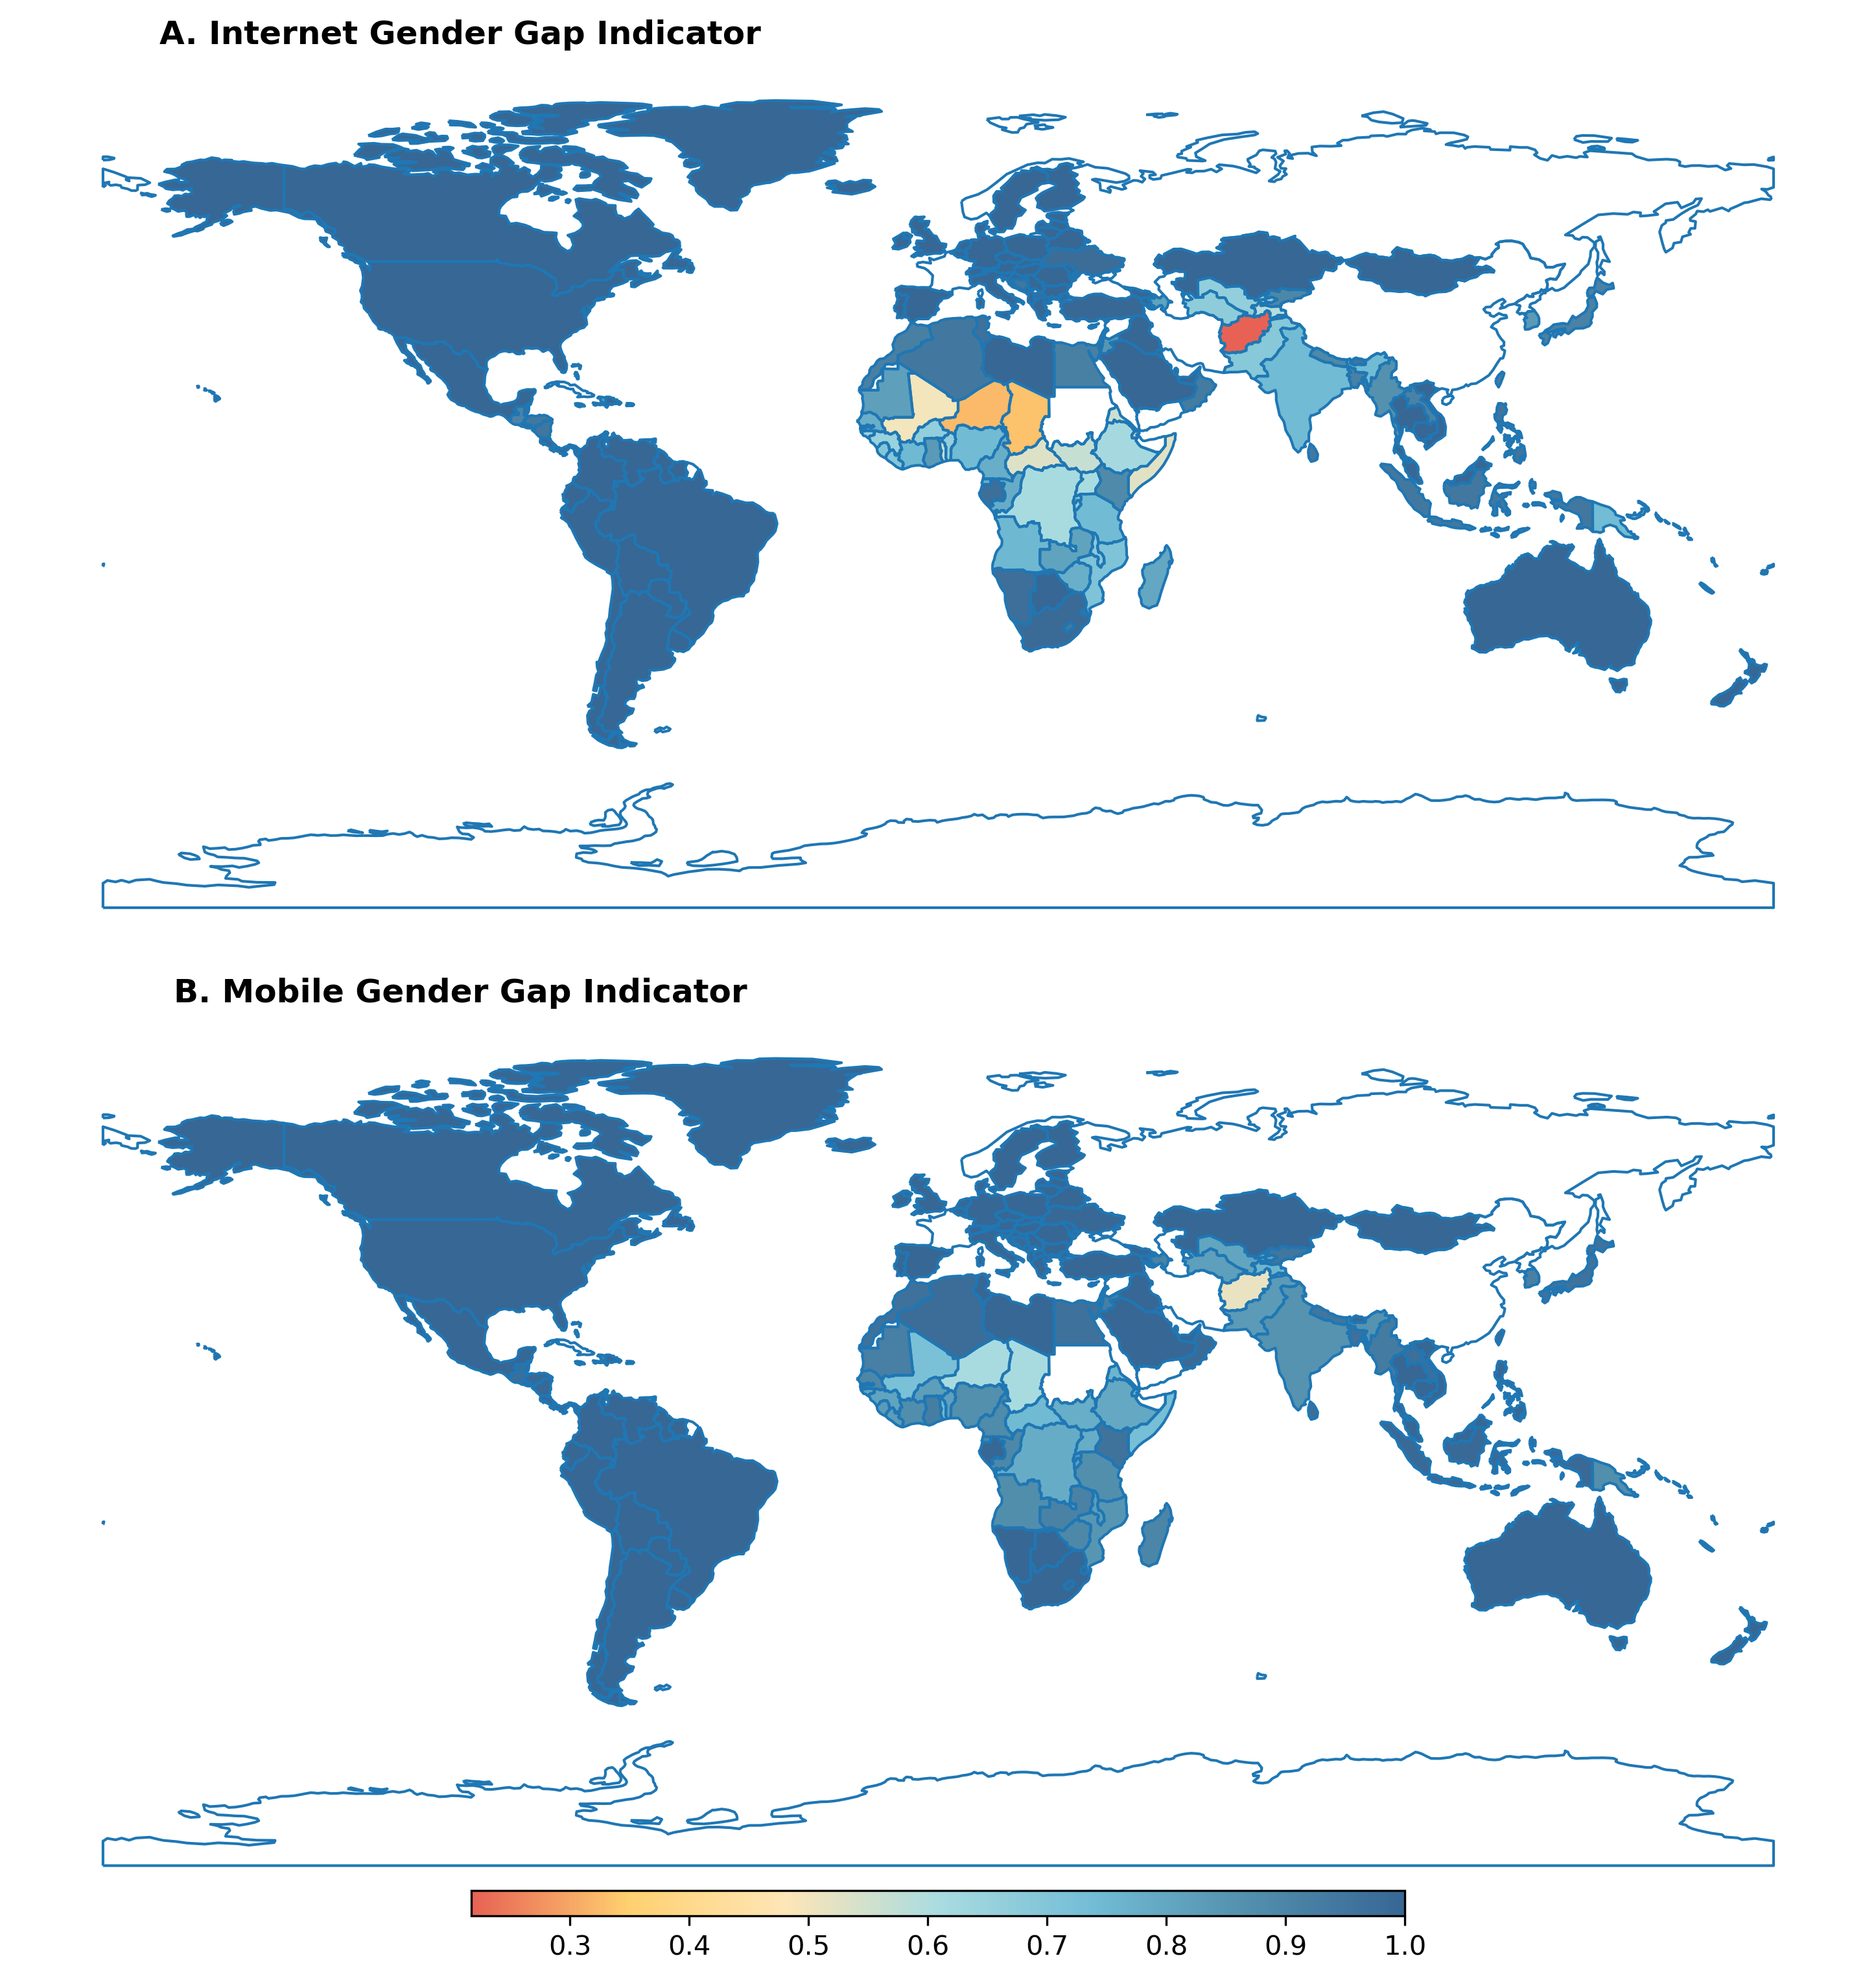

In [5]:
import geopandas as gpd
from matplotlib import pyplot as plt
import matplotlib as mpl
from pathlib import Path

# Load shapefile (update path if needed)
world = gpd.read_file(Path.cwd().parent / params.WORLD_SHP)
#world = world[(world['POP_EST'] > 0) & (world['NAME'] != "Antarctica")]

# Variable settings
outcome_var = 'fm_ratio'
outcome_label = 'Gender Gap Indicator'
indicators = ['internet', 'mobile']

# Prepare subplots (1 row, 2 columns)
fig, axs = plt.subplots(2, 1, figsize=(12,10))

# Determine global vmin and vmax across both indicators for consistent color scale
vmin = df_all_res.loc[
    (df_all_res['outcome'].isin([f'{i}_{outcome_var}' for i in indicators])),
    'predicted'
].min()

vmax = df_all_res.loc[
    (df_all_res['outcome'].isin([f'{i}_{outcome_var}' for i in indicators])),
    'predicted'
].max()

# Plot each indicator's prediction map
for idx, indicator in enumerate(indicators):
    df_res = df_all_res[df_all_res['outcome'] == f'{indicator}_{outcome_var}']

    # Merge predicted values with world map
    world_pred = world.merge(df_res[['gid_0', 'predicted']], left_on='ISO_A3', right_on='gid_0', how='left')

    # Plot boundary and filled map
    world_pred.boundary.plot(ax=axs[idx], linewidth=1)
    world_pred.plot(column='predicted', ax=axs[idx], cmap=custom_cmap, missing_kwds={"color": "white"},
                    vmin=vmin, vmax=vmax)

    if idx == 0:
        axs[idx].set_title(f'A. {indicator.capitalize()} {outcome_label}',fontweight='bold', fontsize=12)# move the title to the left
        
    else:
        axs[idx].set_title(f'B. {indicator.capitalize()} {outcome_label}',fontweight='bold', fontsize=12)
    axs[idx].title.set_position([0.24, 1.05])
    axs[idx].axis('off')

# Add single colorbar
cbar_ax = fig.add_axes([0.3, 0.01, 0.4, 0.013]) 
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')

# Adjust layout
#plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.tight_layout()

#fig.suptitle(f'{current_year} Prediction Maps by Indicator', fontsize=16, fontweight='bold', y=1.05)
plt.savefig(params.FIG / 'fm_ratio_pred_map_by_indicator.pdf', bbox_inches='tight')

# Trends 

In [6]:
model_type = 'combined_with_CIS'

In [7]:
# load data
dropbox_fb_path = params.dropbox_result_path/ f'{model_type}' #params.dropbox_result_path / f'{model_type}'

df_all_res = pd.DataFrame()
for file in dropbox_fb_path.glob("*.csv"):
    # Read the CSV file and concatenate it to df_all_res
    df = pd.read_csv(file)
    df['year'] = df['date'].values[0].split('-')[0]  # Extract year from filename
    df_all_res = pd.concat([df_all_res, df], ignore_index=True)
df_all_res = df_all_res.groupby(['outcome','gid_0','year']).agg({'predicted': 'mean', 'predicted_error': 'mean'}).reset_index()

df_all_res = utils.mark_regions(df_all_res,'gid_0')
df_all_res.drop(df_all_res.loc[df_all_res['gid_0']=='YEM'].index, inplace=True)

## region mean 

In [8]:
facet_label = 'region'
indicator='mobile'
outcome_var = 'fm_ratio'

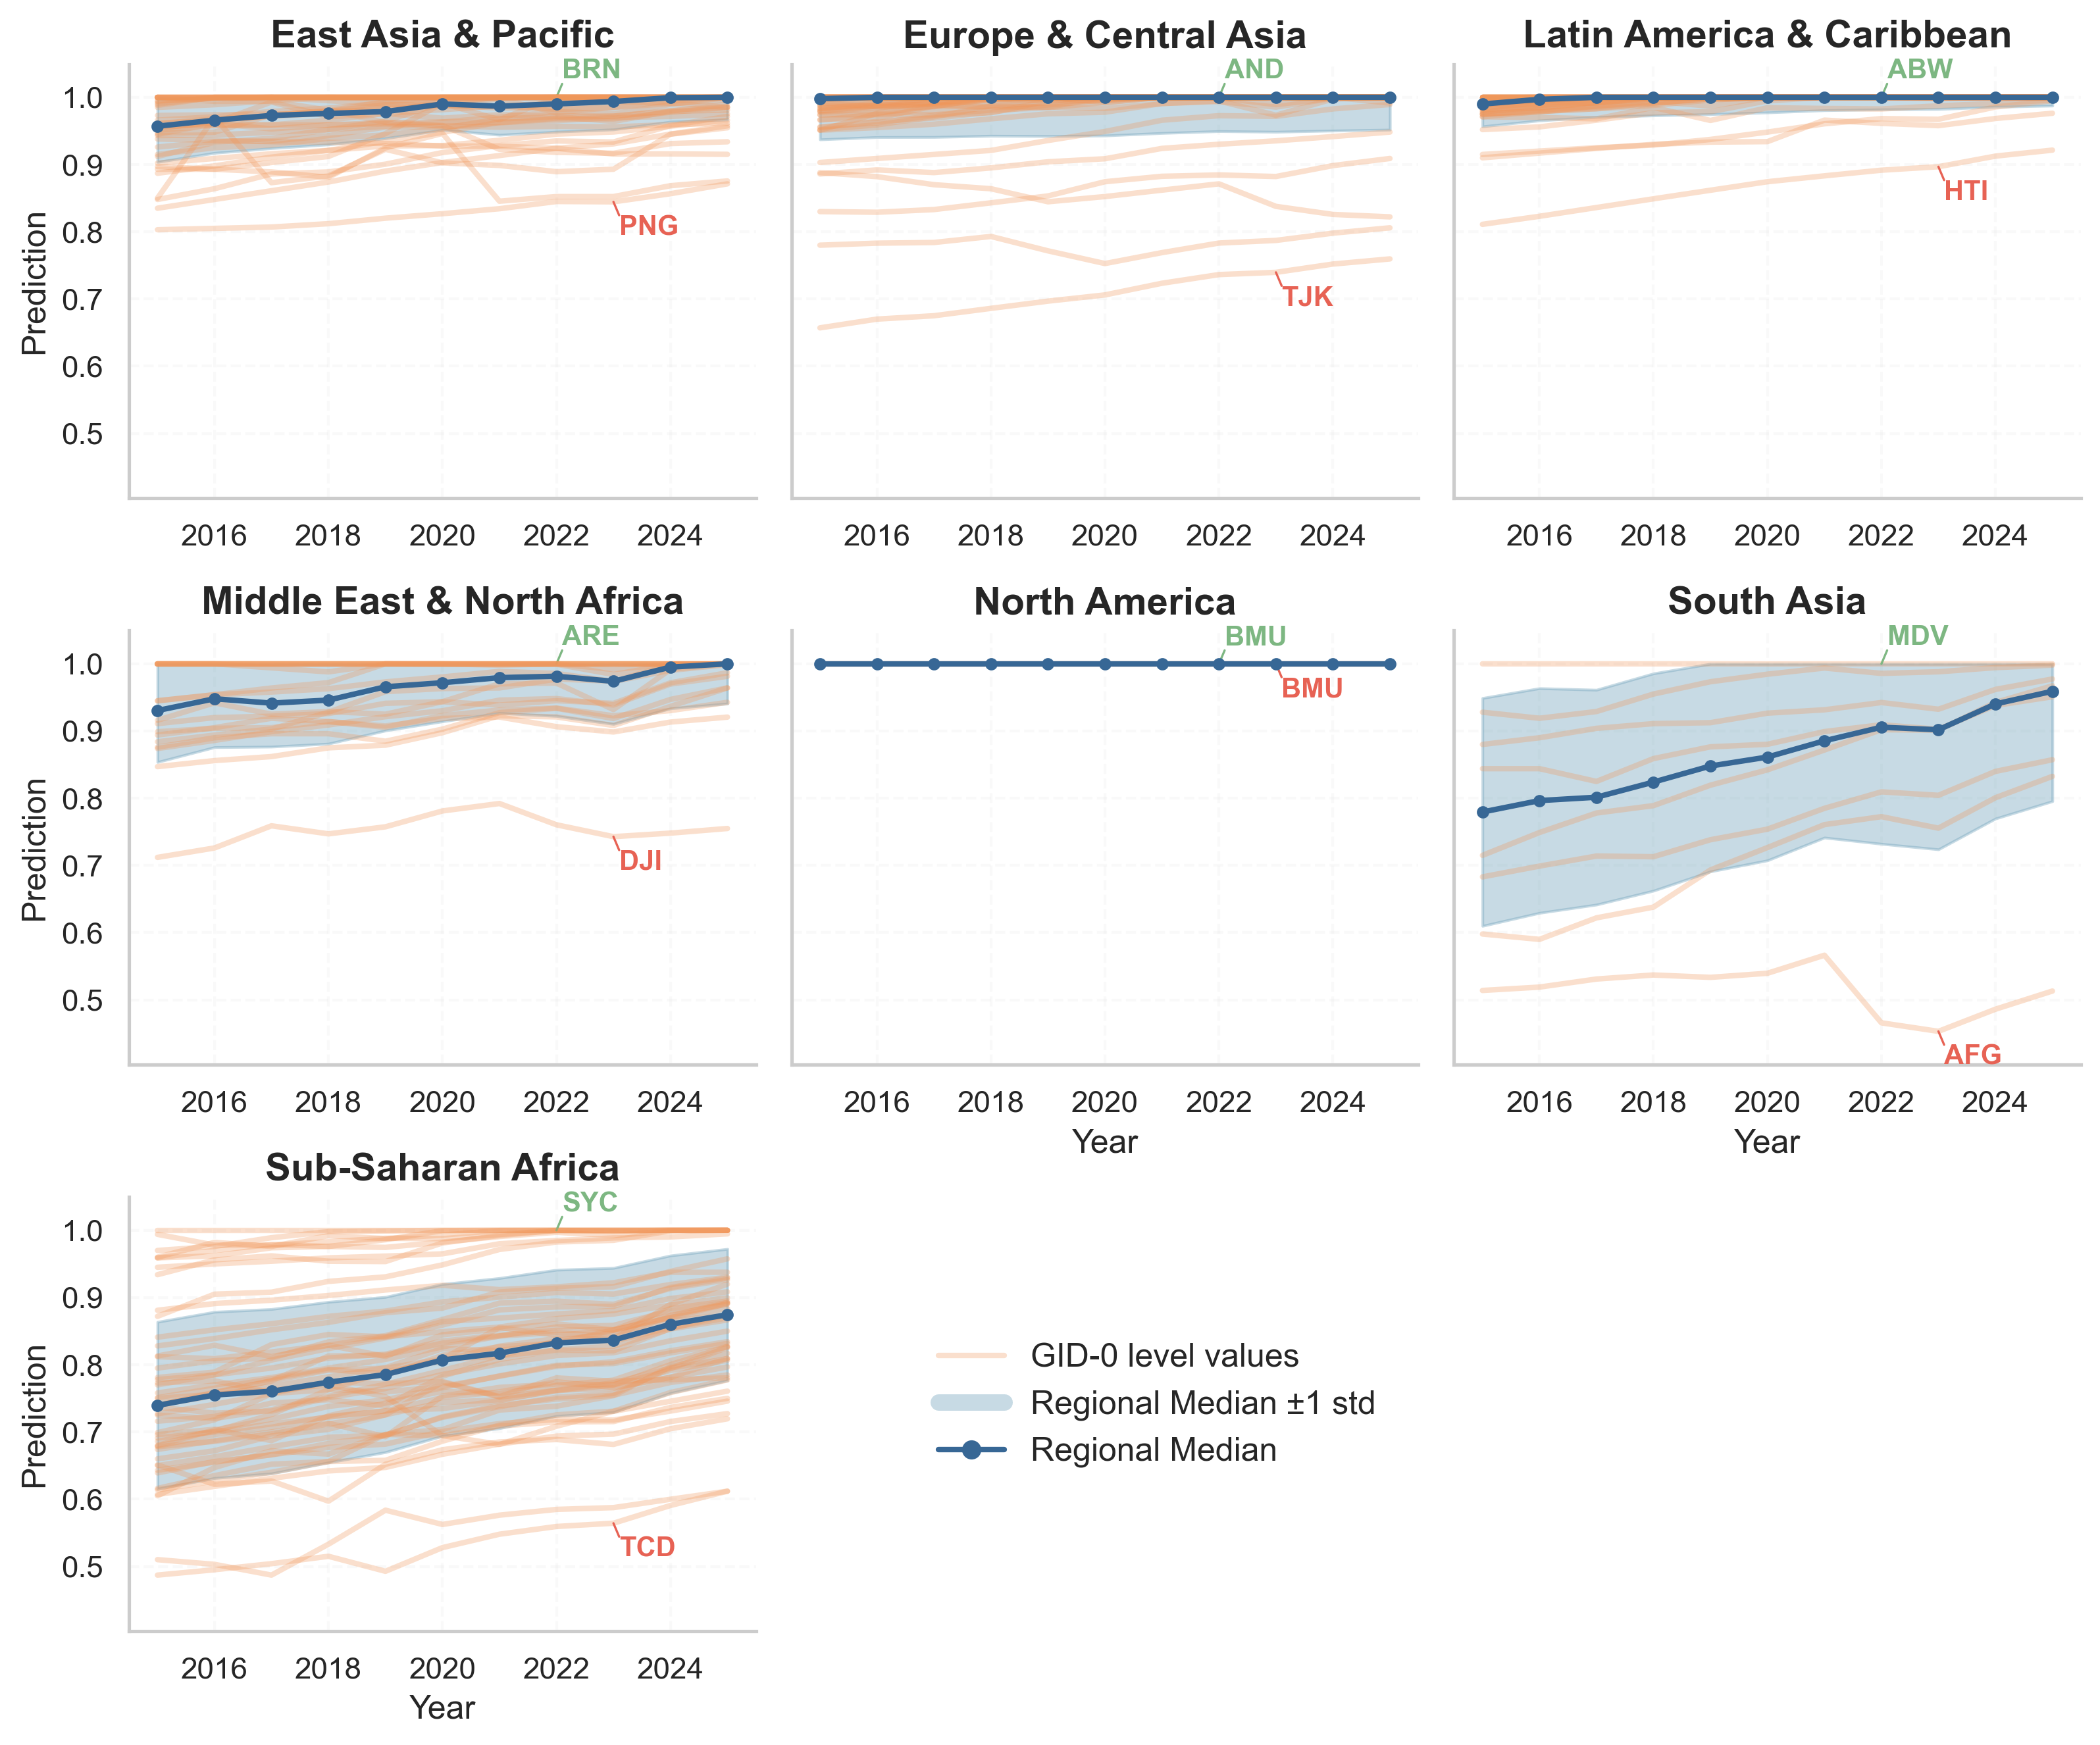

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import numpy as np


# Ensure year is numeric
df_all_res['year'] = pd.to_numeric(df_all_res['year'])
df_all_res = df_all_res[df_all_res['outcome'] == f'{indicator}_{outcome_var}']

# Set seaborn style
sns.set(style="whitegrid")

# Compute regional median and std (for ±1 std shading)


# Compute median, std, and count per region and year
region_stats = df_all_res.groupby([facet_label, 'year'])['predicted'].agg(
    median='median',
    std='std',
    n='count'
).reset_index()
''' 
# Compute 95% CI around the median using std/sqrt(n)
region_stats['ci95'] = 1.96 * (region_stats['std'] / np.sqrt(region_stats['n']))
region_stats['lower'] = region_stats['median'] - region_stats['ci95']
region_stats['upper'] = region_stats['median'] + region_stats['ci95']
'''
region_stats['lower'] =[x if x<=1 else 1 for x in region_stats['median'] - region_stats['std']]
region_stats['upper'] =[x if x<=1 else 1 for x in region_stats['median'] + region_stats['std']]

# Set up FacetGrid
g = sns.FacetGrid(df_all_res, col=facet_label, col_wrap=3, height=3, aspect=1.2)

# Plot each region

for ax, (region_name, region_data) in zip(g.axes.flat, df_all_res.groupby(facet_label)):
    gid_legend_handles = []

    # Compute avg prediction per gid_0
    gid_avg = region_data.groupby('gid_0')['predicted'].mean()
    highest_gid = gid_avg.idxmax()
    lowest_gid = gid_avg.idxmin()

    for gid, group in region_data.groupby('gid_0'):
        group = group.sort_values('year')
        line, = ax.plot(
            group['year'],
            group['predicted'],
            color='#f1975a',
            alpha=0.3,
            linewidth=2,
            label='GID-0 level values'  # add gid label for legend
        )

        if len(gid_legend_handles) < 1:
            gid_legend_handles.append(line)

        # Annotation for highest avg gid_0 (green, near year 2022)
        if gid == highest_gid:
            near_2022 = group.loc[group['year'] == 2022]
            if not near_2022.empty:
                y_val = near_2022['predicted'].values[0]
                ax.text(
                    2022.1,
                    y_val + 0.02,
                    gid,
                    fontsize=10,
                    color='#7db782',
                    va='bottom',
                    ha='left',
                    fontweight='bold'
                )
                # Draw short line from trend to label
                ax.plot(
                    [2022, 2022.1],
                    [y_val, y_val + 0.02],
                    color='#7db782',
                    linewidth=0.8
                )

        # Annotation for lowest avg gid_0 (red, near year 2023)
        if gid == lowest_gid:
            near_2023 = group.loc[group['year'] == 2023]
            if not near_2023.empty:
                y_val = near_2023['predicted'].values[0]
                ax.text(
                    2023.1,
                    y_val - 0.02,
                    gid,
                    fontsize=10,
                    color='#e76254',
                    va='top',
                    ha='left',
                    fontweight='bold'
                )
                # Draw short line from trend to label
                ax.plot(
                    [2023, 2023.1],
                    [y_val, y_val - 0.02],
                    color='#e76254',
                    linewidth=0.8
                )

    # Regional stats
    reg = region_stats[region_stats[facet_label] == region_name]

    ax.fill_between(
        reg['year'],
        reg['lower'],
        reg['upper'],
        color='#73a4bc',
        alpha=0.4,
        label='95% CI'
    )

    ax.plot(
        reg['year'],
        reg['median'],
        color='#376795',
        linewidth=2,
        marker='o',
        markersize=3.5,
        linestyle='-',
        label='Regional Median'
    )

    ax.set_title(region_name, fontsize=14, fontweight='bold')
    ax.set_xlabel("Year")
    ax.set_ylabel("Prediction")
    ax.grid(True, linestyle='--', alpha=0.1)

    #all_years = sorted(region_data['year'].unique())
    #ax.set_xticks(all_years)
    #ax.set_xticklabels(all_years, fontsize=9)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
    ax.tick_params(axis='x', which='both', labelbottom=True)

# Build the legend handles (same as before)
legend_elements = gid_legend_handles + [
    Line2D([0], [0], color='#73a4bc', lw=6, alpha=0.4, label='Regional Median ±1 std'),
    Line2D([0], [0], color='#376795', lw=2, marker='o', label='Regional Median')
]

# Add global legend to the right of the figure
g.fig.legend(
    handles=legend_elements,
    loc='center',
    bbox_to_anchor=(0.55, 0.2),  # Right outside the grid
    borderaxespad=0,
    frameon=False,
    title='',
    fontsize=12
)

plt.tight_layout()
plt.savefig(params.FIG / f'fm_ratio_pred_trend_by_region_{indicator}.pdf', bbox_inches='tight')

## country beta and sigma convergence 

### beta convergence


### Caveat: the ceiling contaminates beta convergence

Both GGI series are clipped to `[0, 1]` upstream, and a large share of country-years sit exactly on
the ceiling — 54.7% for mobile, 32.2% for internet. Where every country in a group reaches 1.0 by
the final year, `delta = 1 - initial` **identically**, so the regression returns `beta = -1.000`,
`R^2 = 1.000` and a vanishing standard error as an arithmetic certainty, not as evidence of
convergence.

South America is the clear case: all 12 countries finish at exactly 1.0 on both indicators. Its row
below should be read as "saturated", not "perfectly convergent". Groups nearer the ceiling are
biased toward stronger apparent convergence in general.

Running this on `{indicator}_ggi_coherent_parity` does not fix it — that measure is capped at
parity too. An uncensored comparison needs the unclipped levels, which the published series does
not retain (D19).

In [10]:
# load data
dropbox_fb_path = params.dropbox_result_path/ f'{model_type}' #params.dropbox_result_path / f'{model_type}'

df_all_res = pd.DataFrame()
for file in dropbox_fb_path.glob("*.csv"):
    # Read the CSV file and concatenate it to df_all_res
    df = pd.read_csv(file)
    df['year'] = df['date'].values[0].split('-')[0]  # Extract year from filename
    df_all_res = pd.concat([df_all_res, df], ignore_index=True)
df_all_res = df_all_res.groupby(['outcome','gid_0','year']).agg({'predicted': 'mean', 'predicted_error': 'mean'}).reset_index()

df_all_res = utils.mark_regions(df_all_res,'gid_0')
df_all_res.drop(df_all_res.loc[df_all_res['gid_0']=='YEM'].index, inplace=True)

df_all_res = df_all_res[df_all_res['outcome'] == f'{indicator}_fm_ratio']

In [11]:
import statsmodels.api as sm

groupby_col = 'conti'  # Change this to 'region' if you want to group by region instead

# Get first and last year
first_year = df_all_res['year'].min()
last_year = df_all_res['year'].max()

# Filter to first and last year
df_beta = df_all_res[df_all_res['year'].isin([first_year, last_year])]
df_pivot = df_beta.pivot_table(index=['gid_0', groupby_col], columns='year', values='predicted').dropna()
df_pivot.columns = ['initial', 'final']
df_pivot['delta'] = df_pivot['final'] - df_pivot['initial']

# -----------------------
# 1. Country-level model
# -----------------------
X_all = sm.add_constant(df_pivot['initial'])
y_all = df_pivot['delta']
model_all = sm.OLS(y_all, X_all).fit()

# Store results
beta_results = [{
    'level': 'Global',
    'n': len(df_pivot),
    'beta': model_all.params['initial'],
    'beta_se': model_all.bse['initial'],
    'r2': model_all.rsquared,
    'pval': model_all.pvalues['initial']
}]

# -----------------------
# 2. Region-level models
# -----------------------
for region, sub in df_pivot.groupby(groupby_col):
    X = sm.add_constant(sub['initial'])
    y = sub['delta']
    model = sm.OLS(y, X).fit()
    
    beta_results.append({
        'level': region,
        'n': len(sub),
        'beta': model.params['initial'],
        'beta_se': model.bse['initial'],
        'r2': model.rsquared,
        'pval': model.pvalues['initial']
    })

# Convert to DataFrame
beta_df = pd.DataFrame(beta_results)


In [12]:
beta_df

,level,n,beta,beta_se,r2,pval
0,Global,213,-0.382667,1.870108e-02,0.664923,5.365546e-52
1,Africa,54,-0.277831,4.334160e-02,0.441410,4.307202e-08
2,Asia,46,-0.360215,6.632633e-02,0.401322,2.296818e-06
3,Europe,46,-0.953640,1.351978e-02,0.991234,6.624481e-47
4,North America,35,-0.656912,2.695042e-02,0.947380,1.120707e-22
5,Oceania,20,-0.494160,1.143632e-01,0.509146,4.115163e-04
6,South America,12,-1.000000,6.581617e-15,1.000000,3.753414e-138


In [13]:
# print beta_df to latex format
# mark p values less than 0.05 with *
# stars key off the p-value (y). The original keyed the first branch off the coefficient (x),
# so any negative beta scored *** regardless of significance — and beta convergence makes
# every beta negative by construction. See D21.
beta_df['beta'] = [f"{x:.3f}***" if y < 0.001 else f"{x:.3f}**" if y < 0.01 else (f"{x:.3f}*" if y < 0.05 else f"{x:.3f}") for x,y in zip(beta_df['beta'], beta_df['pval'])]
print(beta_df.drop(columns=['pval']).to_latex(index=False, float_format="%.3f"))


\begin{tabular}{lrlrr}
\toprule
level & n & beta & beta_se & r2 \\
\midrule
Global & 213 & -0.383*** & 0.019 & 0.665 \\
Africa & 54 & -0.278*** & 0.043 & 0.441 \\
Asia & 46 & -0.360*** & 0.066 & 0.401 \\
Europe & 46 & -0.954*** & 0.014 & 0.991 \\
North America & 35 & -0.657*** & 0.027 & 0.947 \\
Oceania & 20 & -0.494*** & 0.114 & 0.509 \\
South America & 12 & -1.000*** & 0.000 & 1.000 \\
\bottomrule
\end{tabular}



### sigma convergence 

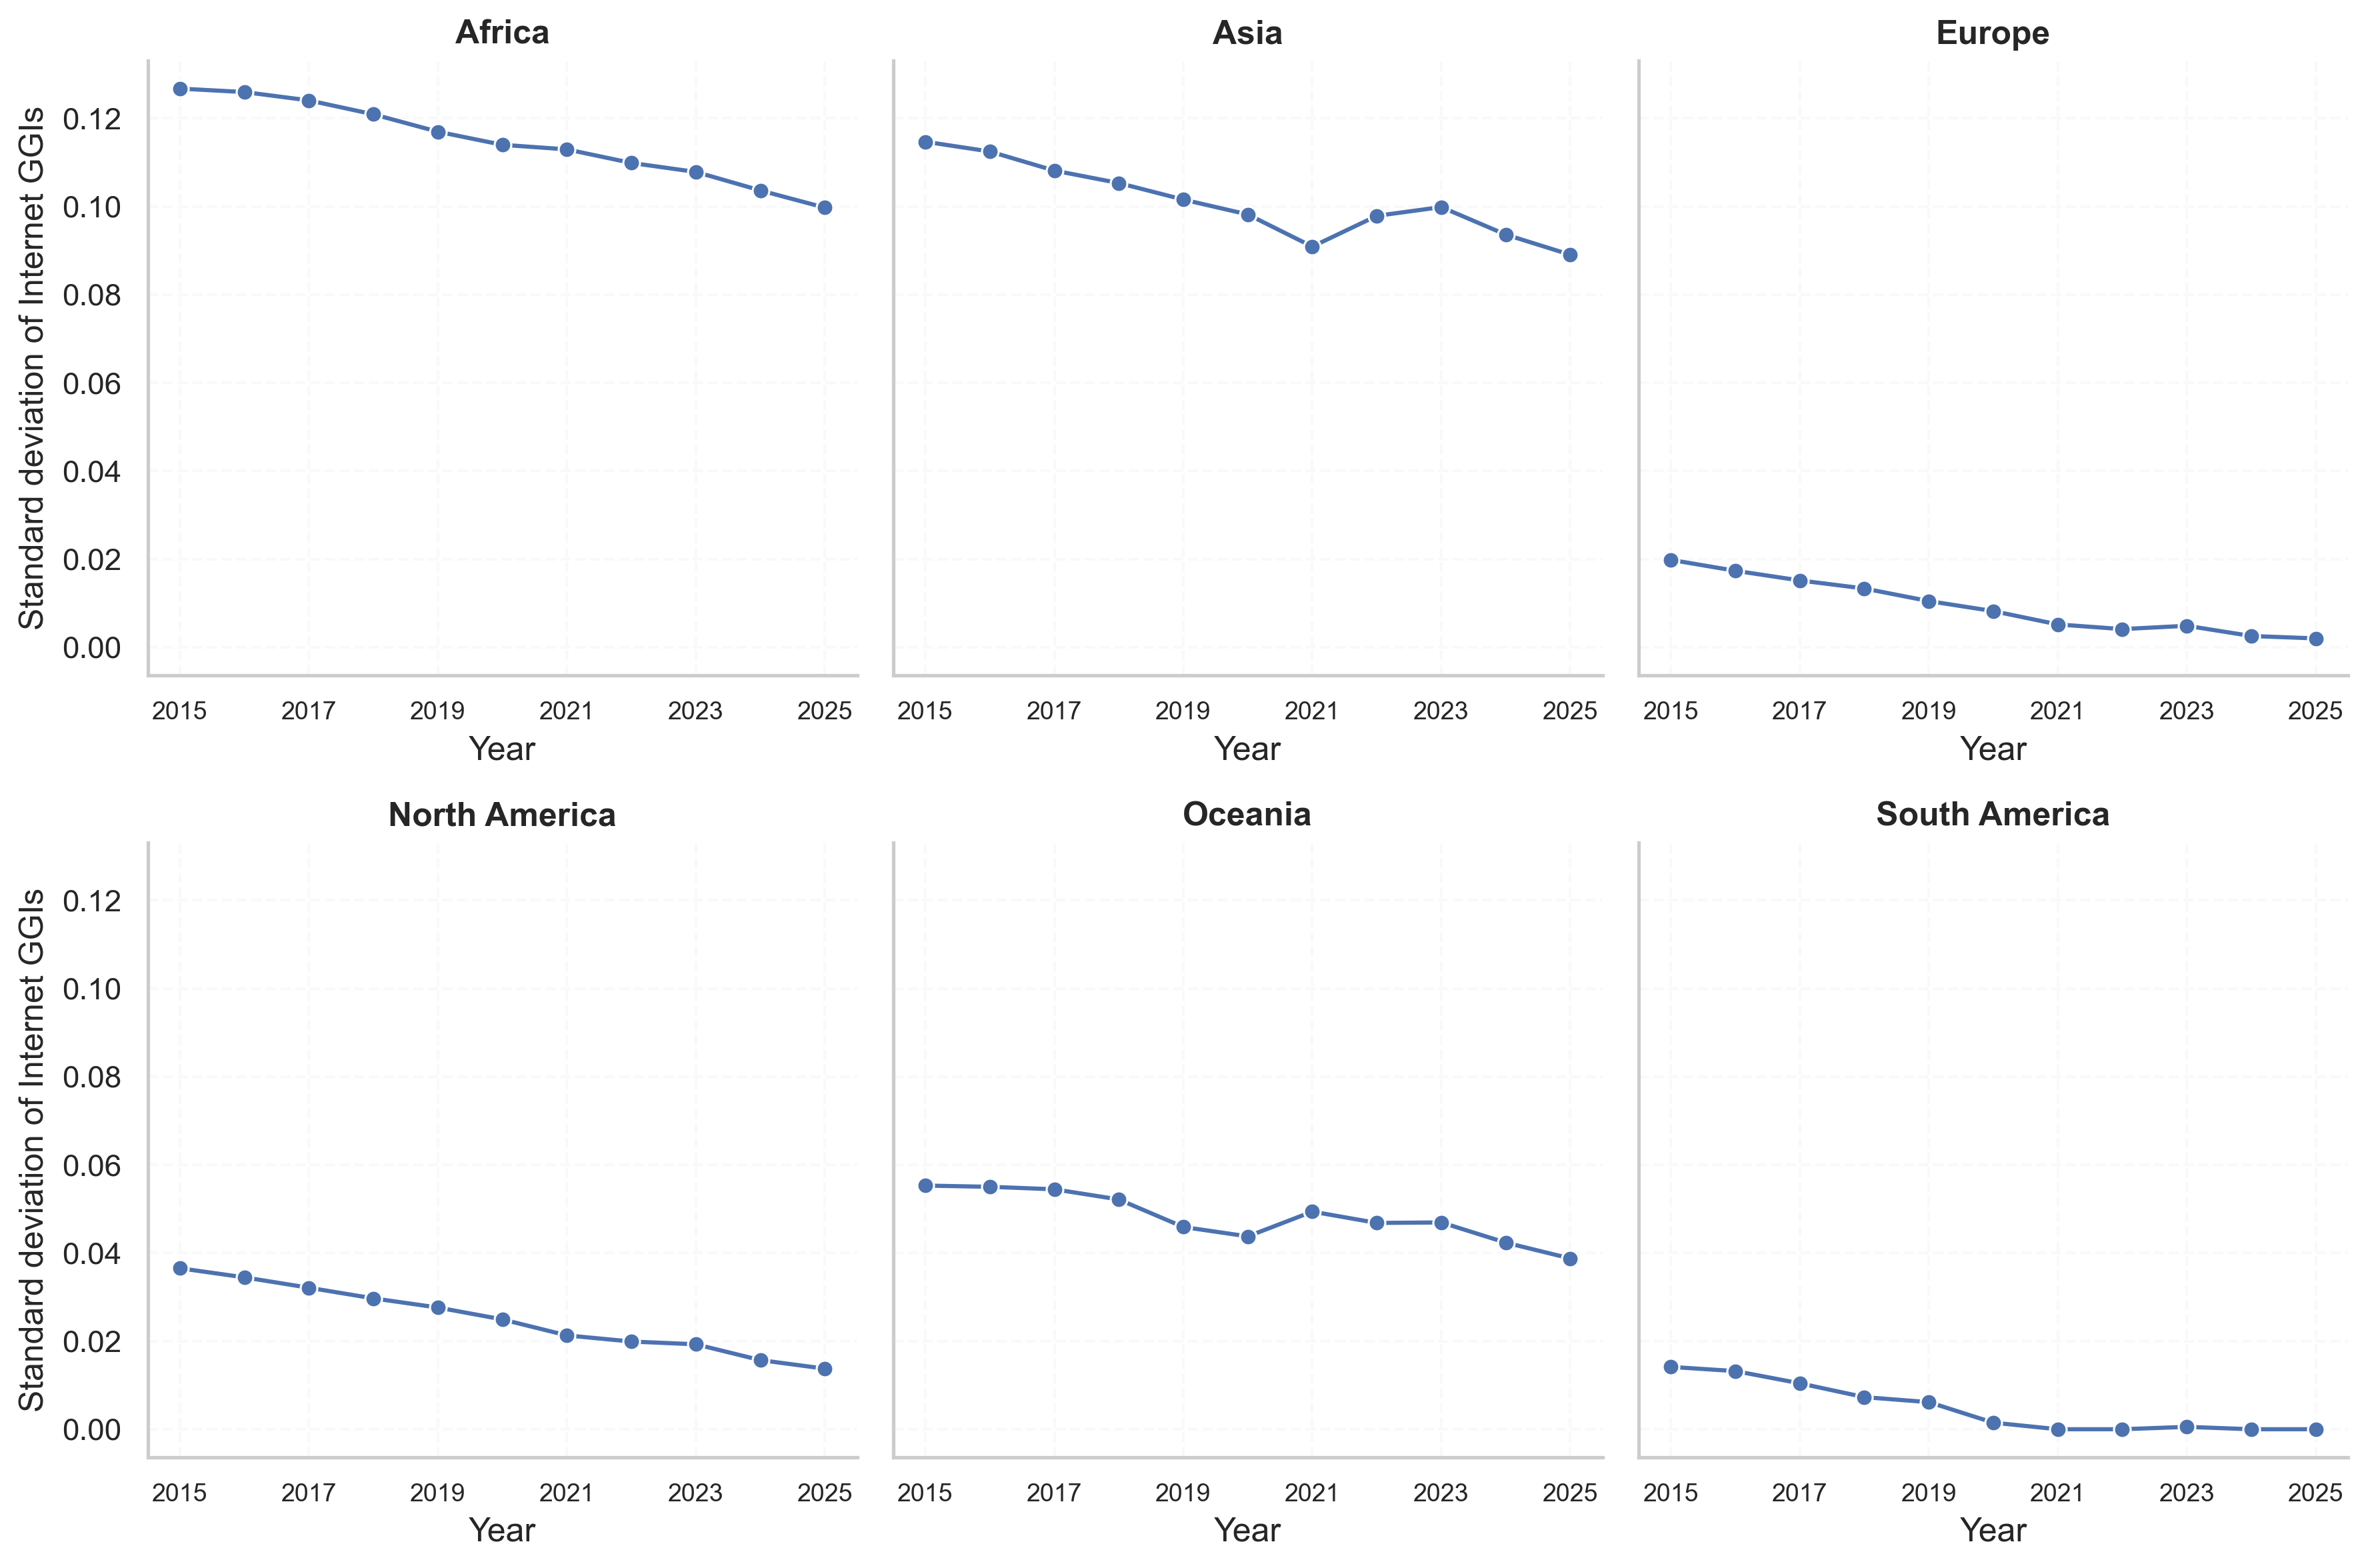

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute sigma convergence
sigma_df = df_all_res.groupby([groupby_col, 'year'])['predicted'].std().reset_index(name='sigma')
sigma_df['year'] = sigma_df['year'].astype(str)  # Convert to string for categorical x-axis

# Create FacetGrid
g = sns.FacetGrid(sigma_df, col=groupby_col, col_wrap=3, height=4, sharex=False)
g.map_dataframe(sns.lineplot, x='year', y='sigma', marker='o')
g.set_axis_labels("Year", "Standard deviation of Internet GGIs")
g.set_titles("{col_name}", fontweight='bold',fontsize=14)

# Get sorted unique years once
years_sorted = sorted(sigma_df['year'].unique(), key=lambda x: int(x))

# Force every subplot to use all years as ticks
for ax in g.axes.flat:
    ax.set_xticks(range(0,len(years_sorted),2))
    ax.set_xticklabels([x for i,x in enumerate(years_sorted) if i%2==0], fontsize=9, rotation=0)
    ax.grid(True, linestyle='--', alpha=0.1)
    ax.set_xlabel("Year",fontsize=12)

plt.tight_layout()
plt.savefig(params.FIG / f'sigma_convergence_by_region_{indicator}.pdf', bbox_inches='tight')